In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('GEOS566HW4.csv')

print(df)

     Year  Day  Time  Ta Min [C]  Ta Max [C]  RH [%]  u [m/s]  Sin [W/m^2]  \
0    2006  135   100       2.160       3.233   73.40    0.556        0.073   
1    2006  135   200       2.663       3.636   83.60    1.032        0.030   
2    2006  135   300       1.825       3.099   89.20    1.003        0.020   
3    2006  135   400       1.858       2.596   91.10    0.823        0.028   
4    2006  135   500       0.818       2.093   94.30    0.996        0.254   
..    ...  ...   ...         ...         ...     ...      ...          ...   
163  2006  141  2000       4.851       6.085   58.51    0.836        0.932   
164  2006  141  2100       4.827       5.666   60.49    0.919       -0.107   
165  2006  141  2200       4.461       6.574   60.09    1.178       -0.351   
166  2006  141  2300       3.896       5.973   63.11    1.350       -0.349   
167  2006  141  2400       4.065       5.944   58.65    1.261        0.051   

     Sout [W/m^2]  Ts [C]  Pa [Hg]  depth [m]        Lat       

In [2]:
#Conversions (DONT RUN THIS MORE THAN ONCE!!!)

df['Time']=df['Time']/100
df['Lat']=np.radians(df['Lat'])
df['dec']=np.radians(df['dec'])
df['Pa [Hg]']=df['Pa [Hg]']*3386.39 #from inHg to Pa
df=df.rename(columns={'Pa [Hg]': 'Pa [Pa]'})

print(df)

     Year  Day  Time  Ta Min [C]  Ta Max [C]  RH [%]  u [m/s]  Sin [W/m^2]  \
0    2006  135   1.0       2.160       3.233   73.40    0.556        0.073   
1    2006  135   2.0       2.663       3.636   83.60    1.032        0.030   
2    2006  135   3.0       1.825       3.099   89.20    1.003        0.020   
3    2006  135   4.0       1.858       2.596   91.10    0.823        0.028   
4    2006  135   5.0       0.818       2.093   94.30    0.996        0.254   
..    ...  ...   ...         ...         ...     ...      ...          ...   
163  2006  141  20.0       4.851       6.085   58.51    0.836        0.932   
164  2006  141  21.0       4.827       5.666   60.49    0.919       -0.107   
165  2006  141  22.0       4.461       6.574   60.09    1.178       -0.351   
166  2006  141  23.0       3.896       5.973   63.11    1.350       -0.349   
167  2006  141  24.0       4.065       5.944   58.65    1.261        0.051   

     Sout [W/m^2]  Ts [C]      Pa [Pa]  depth [m]       Lat    

In [3]:
#Incoming Solar Radiation
w=np.radians(15)
I0=1380 #W/m^2

df['cosZ']=np.sin(df['Lat'])*np.sin(df['dec'])+np.cos(df['Lat'])*np.cos(df['dec'])*np.cos(w*(df['Time']-12))

df['Iin']=I0*df['cosZ']/df['e2']

df.loc[df['Iin']<0,'Iin']=0

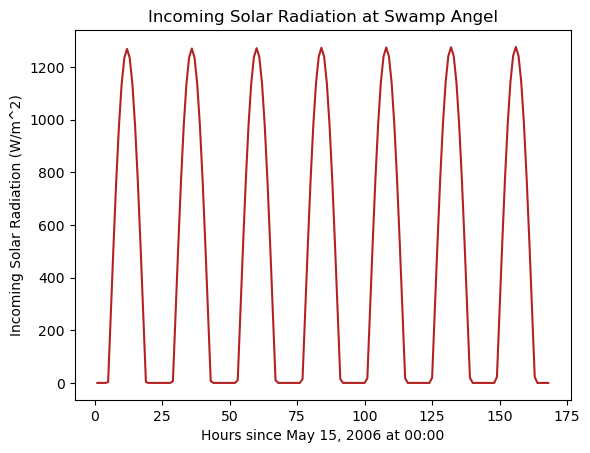

In [4]:
fig, ax = plt.subplots()

df['t']=24*(df['Day']-135)+df['Time']
ax.plot(df['t'], df['Iin'], c='firebrick')
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Incoming Solar Radiation (W/m^2)')
ax.set_title('Incoming Solar Radiation at Swamp Angel')
plt.show()

In [5]:
#Outgoing solar radiation with albedo of 0.65 +/- 0.25

df['Iout']=0.65*df['Iin']
df['Iout_max']=0.9*df['Iin']
df['Iout_min']=0.4*df['Iin']

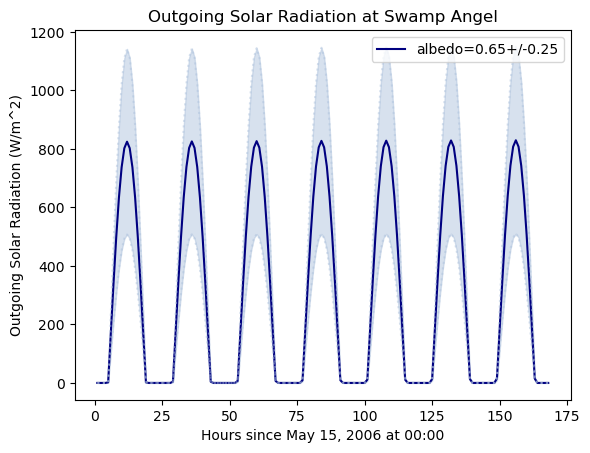

In [6]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['Iout'], c='navy', label='albedo=0.65+/-0.25')
ax.plot(df['t'], df['Iout_max'], c='lightsteelblue', linestyle=':', alpha=0.5)
ax.plot(df['t'], df['Iout_min'], c='lightsteelblue', linestyle=':', alpha=0.5)
ax.fill_between(df['t'], df['Iout_min'], df['Iout_max'], color='lightsteelblue', alpha=0.5)
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Outgoing Solar Radiation (W/m^2)')
ax.set_title('Outgoing Solar Radiation at Swamp Angel')
ax.legend(loc='upper right')
plt.show()

In [7]:
#Net solar radiation

df['Inet']=df['Iin']-df['Iout']
df['Inet_max']=df['Iin']-df['Iout_min']
df['Inet_min']=df['Iin']-df['Iout_max']

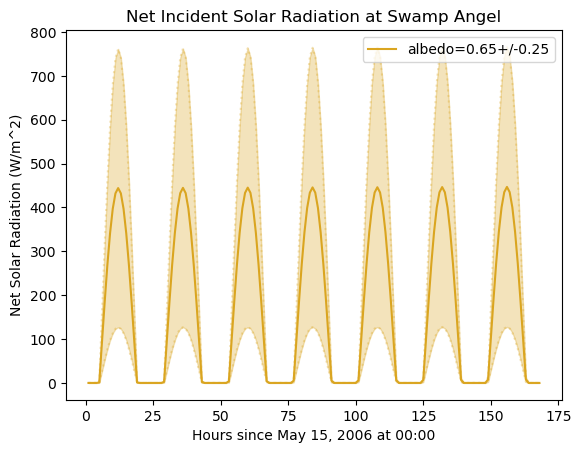

In [8]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['Inet'], c='goldenrod', label='albedo=0.65+/-0.25')
ax.plot(df['t'], df['Inet_max'], c='goldenrod', linestyle=':', alpha=0.3)
ax.plot(df['t'], df['Inet_min'], c='goldenrod', linestyle=':', alpha=0.3)
ax.fill_between(df['t'], df['Inet_min'], df['Inet_max'], color='goldenrod', alpha=0.3)
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Net Solar Radiation (W/m^2)')
ax.set_title('Net Incident Solar Radiation at Swamp Angel')
ax.legend(loc='upper right')
plt.show()

In [9]:
# Incoming longwave radiation

df['Ta_av']=(df['Ta Max [C]']+df['Ta Min [C]'])/2
df['esat']=(1.0007+(3.46*10**-6)*df['Pa [Pa]'])*6.1121*np.exp(17.966*(df['Ta_av'])/(df['Ta_av']+247.15))
df['ea']=df['RH [%]']/100*df['esat']
df['Lin']=0.575*(df['ea']**(1/7))*(5.67*10**-8)*((df['Ta_av']+273.15)**4)

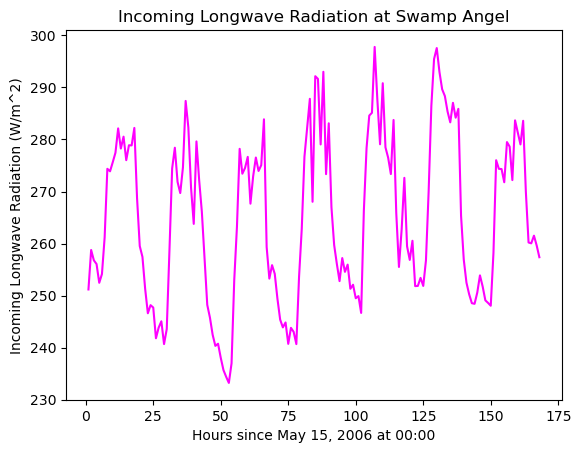

In [10]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['Lin'], c='magenta')
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Incoming Longwave Radiation (W/m^2)')
ax.set_title('Incoming Longwave Radiation at Swamp Angel')
plt.show()

In [11]:
# Outgoing longwave radiation assuming emissivity=0.98

df['Lout']=0.98*(5.67*10**-8)*((df['Ts [C]']+273.15)**4)

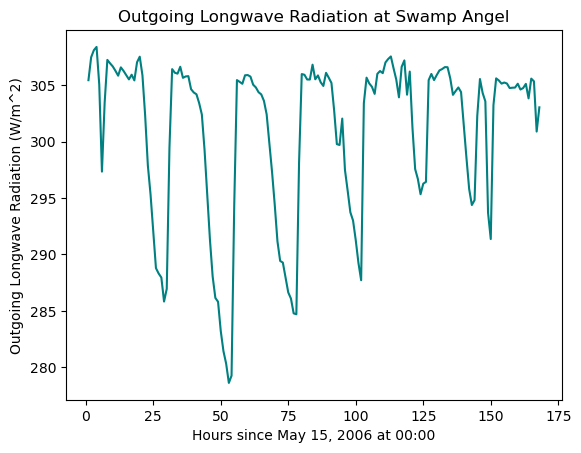

In [12]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['Lout'], c='teal')
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Outgoing Longwave Radiation (W/m^2)')
ax.set_title('Outgoing Longwave Radiation at Swamp Angel')
plt.show()

In [13]:
#Net longwave radiation

df['Lnet']=df['Lin']-df['Lout']

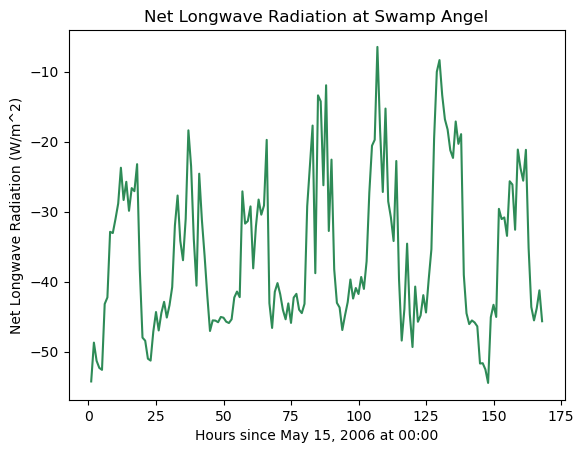

In [14]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['Lnet'], c='seagreen')
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Net Longwave Radiation (W/m^2)')
ax.set_title('Net Longwave Radiation at Swamp Angel')
plt.show()

In [15]:
#Net radiation

df['Rnet']=df['Inet']+df['Lnet']
df['Rnet_max']=df['Inet_max']+df['Lnet']
df['Rnet_min']=df['Inet_min']+df['Lnet']

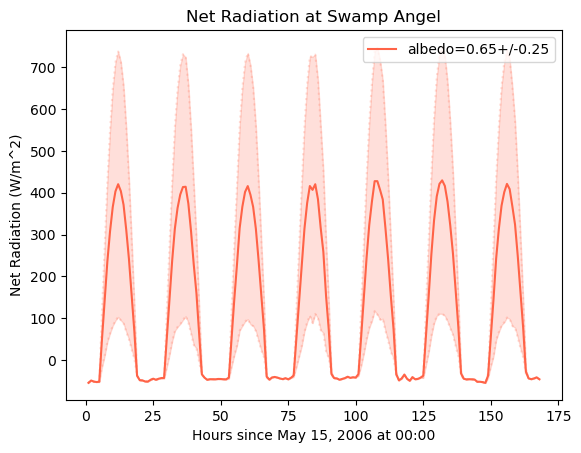

In [16]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['Rnet'], c='tomato', label='albedo=0.65+/-0.25')
ax.plot(df['t'], df['Rnet_max'], c='tomato', linestyle=':', alpha=0.2)
ax.plot(df['t'], df['Rnet_min'], c='tomato', linestyle=':', alpha=0.2)
ax.fill_between(df['t'], df['Rnet_min'], df['Rnet_max'], color='tomato', alpha=0.2)
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Net Radiation (W/m^2)')
ax.set_title('Net Radiation at Swamp Angel')
ax.legend(loc='upper right')
plt.show()

In [17]:
# Sensible heat flux assume snow roughness z0=0.01+/-0.005
df['rhoa']=df['Pa [Pa]']/(287*(df['Ta_av']+273.15))
df['Rib']=(9.81*3.6*(df['Ta_av']-df['Ts [C]']))/(0.5*((df['Ta_av']+273.15)+(df['Ts [C]']+273.15))*df['u [m/s]']**2)
cp=1.005*10**3

df['Chn']=(0.4**2)/(np.log(3.6/0.01)**2)
df['Chn_max']=(0.4**2)/(np.log(3.6/0.005)**2)
df['Chn_min']=(0.4**2)/(np.log(3.6/0.015)**2)

df['Ch']=np.zeros(len(df))
df['Ch_max']=np.zeros(len(df))
df['Ch_min']=np.zeros(len(df))

for i in range(len(df)):
    if df.loc[i,'Rib']>0.4:
        df.loc[i,'Ch']=0
        df.loc[i,'Ch_max']=0
        df.loc[i,'Ch_min']=0
    elif df.loc[i,'Rib']<=0.4 and df.loc[i,'Rib']>0.01:
        df.loc[i,'Ch']=df.loc[i,'Chn']*((1-(5*df.loc[i,'Rib']))**2)
        df.loc[i,'Ch_max']=df.loc[i,'Chn_max']*((1-(5*df.loc[i,'Rib']))**2)
        df.loc[i,'Ch_min']=df.loc[i,'Chn_min']*((1-(5*df.loc[i,'Rib']))**2)
    elif df.loc[i,'Rib']<=0.01 and df.loc[i,'Rib']>=-0.01:
        df.loc[i,'Ch']=df.loc[i,'Chn']
        df.loc[i,'Ch_max']=df.loc[i,'Chn_max']
        df.loc[i,'Ch_min']=df.loc[i,'Chn_min']
    elif df.loc[i,'Rib']<-0.01:
        df.loc[i,'Ch']=df.loc[i,'Chn']*((1-(16*df.loc[i,'Rib']))**0.75)
        df.loc[i,'Ch_max']=df.loc[i,'Chn_max']*((1-(16*df.loc[i,'Rib']))**0.75)
        df.loc[i,'Ch_min']=df.loc[i,'Chn_min']*((1-(16*df.loc[i,'Rib']))**0.75)

df['H']=df['rhoa']*cp*df['Ch']*df['u [m/s]']*(df['Ta_av']-df['Ts [C]'])
df['H_max']=df['rhoa']*cp*df['Ch_max']*df['u [m/s]']*(df['Ta Max [C]']-df['Ts [C]'])
df['H_min']=df['rhoa']*cp*df['Ch_min']*df['u [m/s]']*(df['Ta Min [C]']-df['Ts [C]'])
    

In [ ]:
# My max is crazy high... just checking all the conditions that created it to see if I get the same results calculating by hand.
# print(df.loc[df['H'].idxmax()])

# I do. So I don't think my code is wrong.

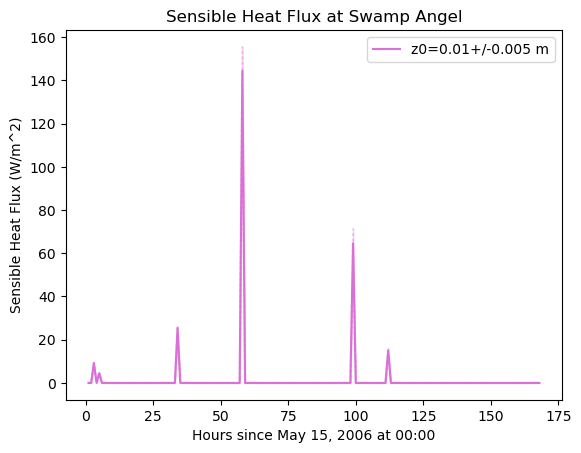

In [18]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['H'], c='orchid', label='z0=0.01+/-0.005 m')
ax.plot(df['t'], df['H_max'], c='orchid', linestyle=':', alpha=0.3)
ax.plot(df['t'], df['H_min'], c='orchid', linestyle=':', alpha=0.3)
ax.fill_between(df['t'], df['H_min'], df['H_max'], color='orchid', alpha=0.3)
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Sensible Heat Flux (W/m^2)')
ax.set_title('Sensible Heat Flux at Swamp Angel')
ax.legend(loc='upper right')
plt.show()

In [19]:
# Latent heat flux assuming snow roughness between (0.005, 0.02) with "typical" set to 0.01 and assuming melt energy goes to melting snow and not warming it (i.e. T=0C)

Lv=333.5*10**3
df['es']=(1.0007+(3.46*10**-6)*df['Pa [Pa]'])*611.21*np.exp(17.966*(df['Ts [C]'])/(df['Ts [C]']+247.15))

df['QL']=df['rhoa']*0.622*Lv/df['Pa [Pa]']*df['Ch']*df['u [m/s]']*(df['es']-df['ea'])
df['QL_max']=df['rhoa']*0.622*Lv/df['Pa [Pa]']*df['Ch_max']*df['u [m/s]']*(df['es']-df['ea'])
df['QL_min']=df['rhoa']*0.622*Lv/df['Pa [Pa]']*df['Ch_min']*df['u [m/s]']*(df['es']-df['ea'])

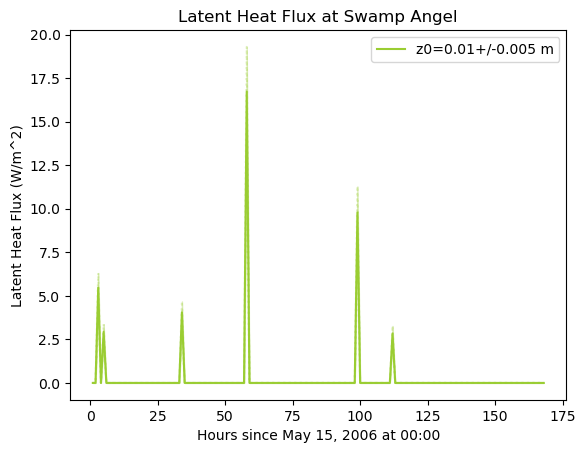

In [20]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['QL'], c='yellowgreen', label='z0=0.01+/-0.005 m')
ax.plot(df['t'], df['QL_max'], c='yellowgreen', linestyle=':', alpha=0.3)
ax.plot(df['t'], df['QL_min'], c='yellowgreen', linestyle=':', alpha=0.3)
ax.fill_between(df['t'], df['QL_min'], df['QL_max'], color='yellowgreen', alpha=0.3)
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Latent Heat Flux (W/m^2)')
ax.set_title('Latent Heat Flux at Swamp Angel')
ax.legend(loc='upper right')
plt.show()

In [21]:
# Total energy flux at snow surface

df['Qtotal']=df['Rnet']+df['H']+df['QL']
df['Qtotal_max']=df['Rnet_max']+df['H_max']+df['QL_max']
df['Qtotal_min']=df['Rnet_min']+df['H_min']+df['QL_min']

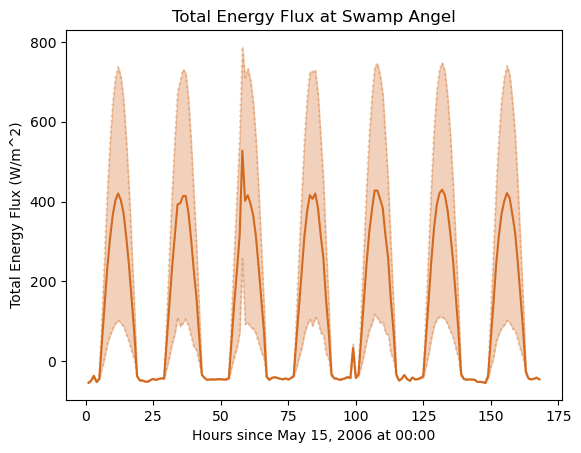

In [22]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['Qtotal'], c='chocolate')
ax.plot(df['t'], df['Qtotal_max'], c='chocolate', linestyle=':', alpha=0.3)
ax.plot(df['t'], df['Qtotal_min'], c='chocolate', linestyle=':', alpha=0.3)
ax.fill_between(df['t'], df['Qtotal_min'], df['Qtotal_max'], color='chocolate', alpha=0.3)
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Total Energy Flux (W/m^2)')
ax.set_title('Total Energy Flux at Swamp Angel')
plt.show()


In [23]:
# Estimated melt for each time step assuming all energy goes to melting snow and not warming it (i.e. T=0C), answers presented as depth of melt in mm for each hour time step.

df['M_est']=df['Qtotal']/(Lv*1000)*3600*1000
df['M_est']=df['M_est'].clip(lower=0)
df['M_est_max']=df['Qtotal_max']/(Lv*1000)*3600*1000
df['M_est_max']=df['M_est_max'].clip(lower=0)
df['M_est_min']=df['Qtotal_min']/(Lv*1000)*3600*1000
df['M_est_min']=df['M_est_min'].clip(lower=0)

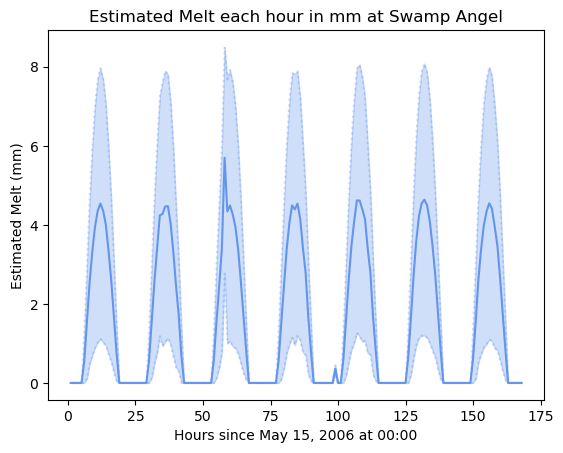

In [24]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['M_est'], c='cornflowerblue')
ax.plot(df['t'], df['M_est_max'], c='cornflowerblue', linestyle=':', alpha=0.3)
ax.plot(df['t'], df['M_est_min'], c='cornflowerblue', linestyle=':', alpha=0.3)
ax.fill_between(df['t'], df['M_est_min'], df['M_est_max'], color='cornflowerblue', alpha=0.3)
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Estimated Melt (mm)')
ax.set_title('Estimated Melt each hour in mm at Swamp Angel')
plt.show()

In [25]:
# Now estimating melt with measured incoming and outgoing solar radiation

df['Qtot_meas']=(df['Sout [W/m^2]']-df['Sin [W/m^2]'])#+df['H']+df['QL']+df['Lnet']
df['M_meas']=df['Qtot_meas']/(Lv*1000)*3600*1000
df['M_meas']=df['M_meas'].clip(lower=0)



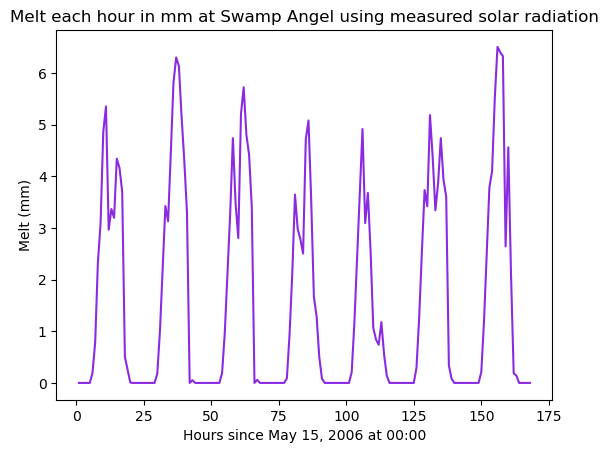

In [26]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['M_meas'], c='blueviolet')
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Melt (mm)')
ax.set_title('Melt each hour in mm at Swamp Angel using measured solar radiation')
plt.show()

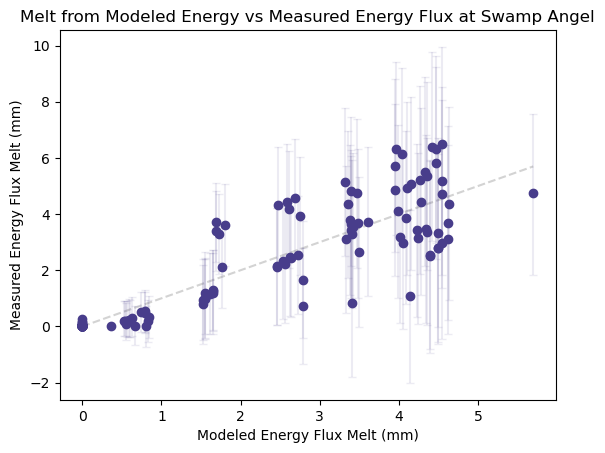

In [27]:
fig, ax = plt.subplots()

x = np.linspace(0, max(df['M_est']), 100)
y = x

lower= (df['M_est'] - df['M_est_min']).clip(lower=0)
upper= (df['M_est_max'] - df['M_est']).clip(lower=0)
yerr=[lower, upper]

ax.plot(x, y, c='lightgray', linestyle='--', zorder=-1)
ax.scatter(df['M_est'], df['M_meas'], c='darkslateblue')
ax.errorbar(df['M_est'], df['M_meas'], yerr=yerr,fmt='none',ecolor='darkslateblue', alpha=0.1, capsize=3)

ax.set_xlabel('Modeled Energy Flux Melt (mm)')
ax.set_ylabel('Measured Energy Flux Melt (mm)')
ax.set_title('Melt from Modeled Energy vs Measured Energy Flux at Swamp Angel')

plt.show()

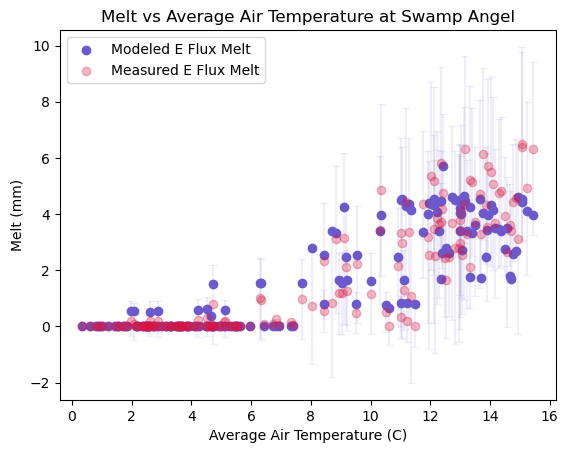

In [28]:
# Melt versus air temp

fig, ax = plt.subplots()

ax.scatter(df['Ta_av'], df['M_est'], c='slateblue', label='Modeled E Flux Melt')
ax.errorbar(df['Ta_av'], df['M_meas'], yerr=yerr,fmt='none',ecolor='slateblue', alpha=0.1, capsize=3, zorder=-10)
ax.scatter(df['Ta_av'], df['M_meas'], c='crimson', label='Measured E Flux Melt', alpha=0.3, zorder=1000)
ax.legend(loc='upper left')
ax.set_xlabel('Average Air Temperature (C)')
ax.set_ylabel('Melt (mm)')
ax.set_title('Melt vs Average Air Temperature at Swamp Angel')
plt.show()

In [29]:
# What's left! New snow depths considering melt

df['Dmod']=df['depth [m]'].max()
df['Dmod_max']=df['depth [m]'].max()
df['Dmod_min']=df['depth [m]'].max()
df['Dmeas']=df['depth [m]'].max()

for i in range(len(df)-1):
    df.loc[i+1,'Dmod']=df.loc[i,'Dmod']-(df.loc[i,'M_est']/1000)
    df.loc[i+1,'Dmod_max']=df.loc[i,'Dmod_max']-(df.loc[i,'M_est_max']/1000)
    df.loc[i+1,'Dmod_min']=df.loc[i,'Dmod_min']-(df.loc[i,'M_est_min']/1000)
    df.loc[i+1,'Dmeas']=df.loc[i,'Dmeas']-(df.loc[i,'M_meas']/1000)

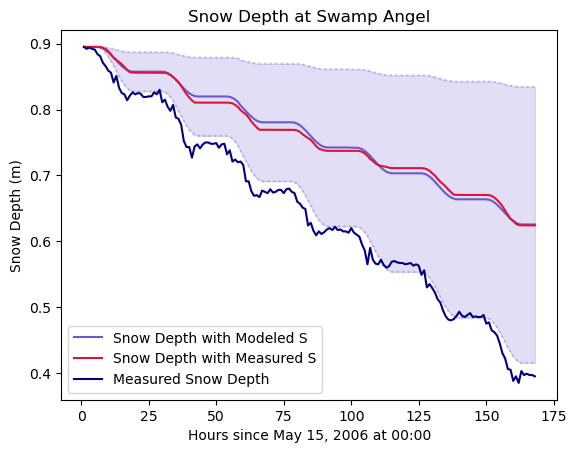

In [31]:
fig, ax = plt.subplots()

ax.plot(df['t'], df['Dmod'], c='slateblue', label='Snow Depth with Modeled S')
ax.plot(df['t'], df['Dmod_max'], c='slateblue', linestyle=':', alpha=0.3)
ax.plot(df['t'], df['Dmod_min'], c='slateblue', linestyle=':', alpha=0.3)
ax.fill_between(df['t'], df['Dmod_min'], df['Dmod_max'], color='slateblue', alpha=0.2)
ax.plot(df['t'], df['Dmeas'], c='crimson', label='Snow Depth with Measured S')
ax.plot(df['t'], df['depth [m]'], c='navy', label='Measured Snow Depth')
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Snow Depth (m)')
ax.set_title('Snow Depth at Swamp Angel')
ax.legend(loc='lower left')
plt.show()

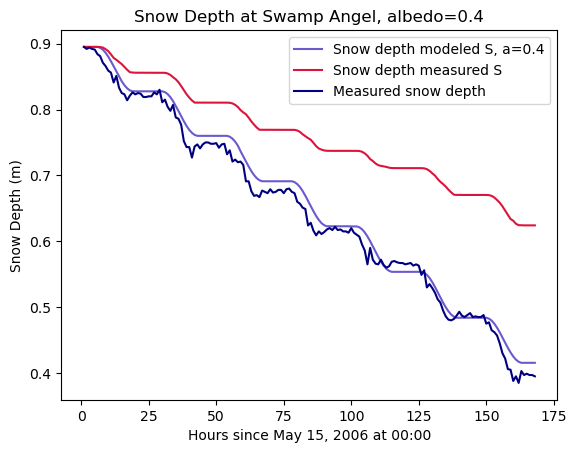

In [32]:
# Best fit is clearly albedo=0.4! Maximum modeled melt.

fig, ax = plt.subplots()

ax.plot(df['t'], df['Dmod_max'], c='slateblue', label='Snow depth modeled S, a=0.4')
ax.plot(df['t'], df['Dmeas'], c='crimson', label='Snow depth measured S')
ax.plot(df['t'], df['depth [m]'], c='navy', label='Measured snow depth')
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Snow Depth (m)')
ax.set_title('Snow Depth at Swamp Angel, albedo=0.4')
ax.legend(loc='upper right')
plt.show()

-0.00036700276635541143
-0.0003903596475282006


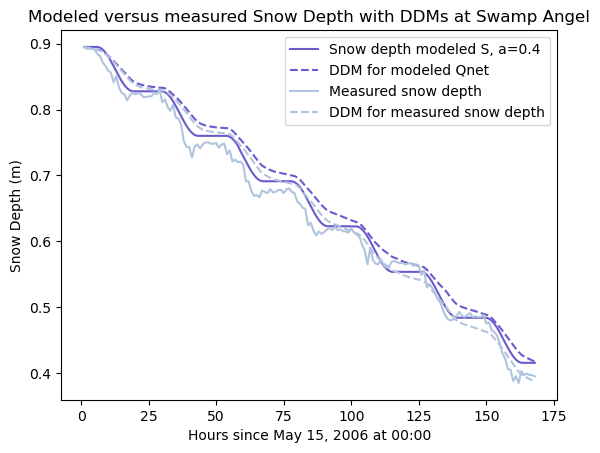

In [33]:
df.loc[df['Ta_av']<0, 'Ta_av']=0

delSWE_mod=df['Dmod_max'].min()-df['Dmod_max'].max()
delSWE_meas=df['depth [m]'].min()-df['depth [m]'].max()
Tpos=df['Ta_av'].sum()

ddf_mod=delSWE_mod/Tpos
ddf_meas=delSWE_meas/Tpos

df['ddm_mod']=np.zeros(len(df))
df['ddm_meas']=np.zeros(len(df))
df.loc[0,'ddm_mod']=df['depth [m]'].max()
df.loc[0,'ddm_meas']=df['depth [m]'].max()

print(ddf_mod)
print(ddf_meas)

for i in range(len(df)-1):
    df.loc[i+1,'ddm_mod']=df.loc[i,'ddm_mod']+ddf_mod*df.loc[i,'Ta_av']
    df.loc[i+1,'ddm_meas']=df.loc[i,'ddm_meas']+ddf_meas*df.loc[i,'Ta_av']

fig, ax = plt.subplots()

ax.plot(df['t'], df['Dmod_max'], c='slateblue', label='Snow depth modeled S, a=0.4')
ax.plot(df['t'], df['ddm_mod'], c='slateblue', linestyle='--', label='DDM for modeled Qnet')
ax.plot(df['t'], df['depth [m]'], c='lightsteelblue', label='Measured snow depth')
ax.plot(df['t'], df['ddm_meas'], c='lightsteelblue', linestyle='--', label='DDM for measured snow depth')
ax.set_xlabel('Hours since May 15, 2006 at 00:00')
ax.set_ylabel('Snow Depth (m)')
ax.set_title('Modeled versus measured Snow Depth with DDMs at Swamp Angel')
ax.legend(loc='upper right')
plt.show()